
# ANN for APPENDICITIS PREDICTION
Wanchana Phuphansakun (35497001)


#1 IMPORTS & SETUP

In [ ]:
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set rondom seed of numpy and tensorflow to get similar result everytime.
np.random.seed(1)
tf.random.set_seed(1)

CSV_PATH   = "Regensburg Pediatric Appendicitis.csv"
TARGET_COL = "Diagnosis"                              # the column that will be used for predictions.
MODEL_PATH = "appendicitis_tf.keras"
META_PATH  = "appendicitis_tf_meta.json"


#2. LOAD and CLEAN DATA

In [ ]:
df = pd.read_csv(CSV_PATH)


# this will strip every columns in the csv
df.columns = [c.strip() for c in df.columns]

# drop any coloumns that is "unnamed"
id_like = [c for c in df.columns if c.lower().startswith("unnamed")]
df = df.drop(columns=id_like, errors="ignore")

print("Columns in dataset:")
print(df.columns.tolist())

print("\nPreview of Diagnosis column:")
print(df[TARGET_COL].head(10))


Columns in dataset:
['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'US_Number', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'Enteritis', 'Gynecological_Findings', 'Management', 'Severit

#3. MAP DIANOSIS COLUMN to BINARY LABEL 0 or 1

In [ ]:
# This will turn appendictis to 1 and no appendictis to 0.
y_raw = df[TARGET_COL].astype(str).str.strip().str.lower()

def map_diagnosis(v: str):
    v = v.strip().lower()
    if "no append" in v:      # e.x. "no appendicitis"
        return 0
    elif "append" in v:       # e.x. "appendicitis"
        return 1
    else:
        return np.nan         # set data to NaN and drop later

y_mapped = y_raw.apply(map_diagnosis)

print("\nClass counts BEFORE dropping NaN:")
print(y_mapped.value_counts(dropna=False))

# Drop row that contains NaN.
mask_valid = y_mapped.notna()
# Show number of droped rows.
if (~mask_valid).sum() > 0:
    print("\nDropping rows with no valid label:", (~mask_valid).sum())

df = df[mask_valid].copy()
y = y_mapped[mask_valid].astype(int).to_numpy()

print("\nClass counts AFTER dropping NaN:")
print(pd.Series(y).value_counts())



Class counts BEFORE dropping NaN:
Diagnosis
1.0    463
0.0    317
NaN      2
Name: count, dtype: int64

Dropping rows with no valid label: 2

Class counts AFTER dropping NaN:
1    463
0    317
Name: count, dtype: int64


#4. BUILD FEATURES X

---



In [ ]:
# Prepare data X to for trianing.
X = df.drop(columns=[TARGET_COL])

# check for infinite values and replace with nan.
X = X.replace([np.inf, -np.inf], np.nan)

# This line will convert catregory or text columns into numeric for the model.
X_encoded = pd.get_dummies(X, drop_first=True, dummy_na=True)

# This line will fill the NaN with the median of each column.
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))

feature_cols = list(X_encoded.columns)
print("Total encoded feature columns:", len(feature_cols))
print("First 15 feature columns:", feature_cols[:15])


Total encoded feature columns: 154
First 15 feature columns: ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'RBC_Count', 'Hemoglobin', 'RDW']


#5. SPLIT DATA to TRAIN/TEST

In [ ]:
from sklearn.model_selection import train_test_split

X_all = X_encoded.to_numpy(dtype=np.float32)
y_all = y

def safe_train_test_split(X_all, y_all):
    try:
        return train_test_split(
            X_all, y_all,
            test_size=0.20, # split 20% of the dataset into test set.
            random_state=42,
            stratify=y_all
        )
    except ValueError:
        print("Stratified split failed, falling back to normal shuffle split.")
        return train_test_split(
            X_all, y_all,
            test_size=0.20,
            random_state=42,
            shuffle=True,
            stratify=None
        )

X_train, X_test, y_train, y_test = safe_train_test_split(X_all, y_all)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test  class balance:", np.bincount(y_test))


Train shape: (624, 154) Test shape: (156, 154)
Train class balance: [254 370]
Test  class balance: [63 93]


#6. BUILD MODEL (ANN use Keras)

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)), # This is the input layer
    layers.Dense(32, activation="relu"), # This is first hidden layer with 32 neurons and "relu" activation
    layers.Dropout(0.4), # This layer will dropout 40% of the neurons during training. To anti-overfitting
    layers.Dense(16, activation="relu"), # This is second hidden layer with 16 neurons and "relu" activation
    layers.Dropout(0.3), # This layer will dropout 30% of the neurons during training. To anti-overfitting
    layers.Dense(1, activation="sigmoid"),  # This is the output layer with 1 neuron output and "sigmoid" activation
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3), # This will set optimizer to Adam optimizer with 0.001 learning rate.
    loss="binary_crossentropy", # To measure how wrong the model is.
    metrics=[
        keras.metrics.AUC(name="auc"),
        "accuracy"
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         4,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

#7. TRAIN MODEL

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8029 - auc: 0.9159 - loss: 0.3586 - val_accuracy: 0.8960 - val_auc: 0.9557 - val_loss: 0.3107
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7558 - auc: 0.8732 - loss: 0.4099 - val_accuracy: 0.8560 - val_auc: 0.9480 - val_loss: 0.3800
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8198 - auc: 0.8942 - loss: 0.3799 - val_accuracy: 0.8880 - val_auc: 0.9507 - val_loss: 0.3261
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7997 - auc: 0.8849 - loss: 0.3884 - val_accuracy: 0.8880 - val_auc: 0.9433 - val_loss: 0.3308
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7697 - auc: 0.8618 - loss: 0.4016 - val_accuracy: 0.9040 - val_auc: 0.9516 - val_loss: 0.3273
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8056 - auc: 0.8782 - loss: 0.3745 - val_accuracy: 0.8800 - val_auc: 0.9507 - val_loss: 0.3235
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

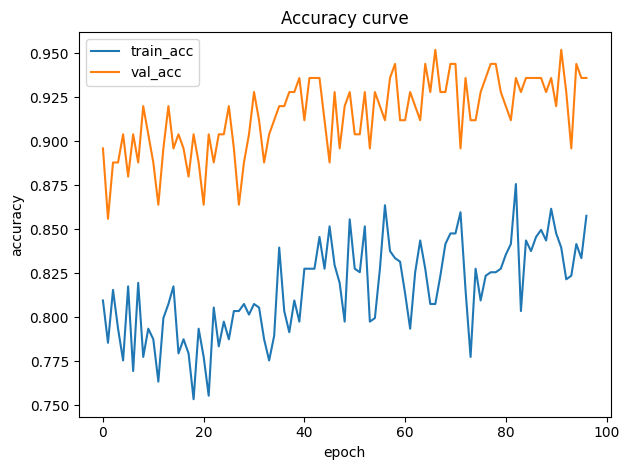

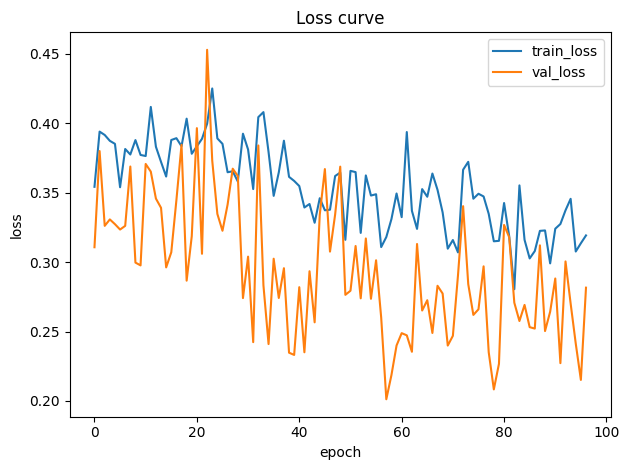

In [ ]:
es = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

print("Training done.")

# put training history to variables
train_acc_history  = history.history["accuracy"]
val_acc_history    = history.history["val_accuracy"]
train_loss_history = history.history["loss"]
val_loss_history   = history.history["val_loss"]
val_auc_history    = history.history["val_auc"]

final_train_acc  = train_acc_history[-1]
final_val_acc    = val_acc_history[-1]
final_train_loss = train_loss_history[-1]
final_val_loss   = val_loss_history[-1]
best_val_auc     = max(val_auc_history)

print("==== Training summary ====")
print(f"Final Train Accuracy      : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Final Train Loss          : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Best Validation AUC       : {best_val_auc:.4f}")

# Plot learning curves
import matplotlib.pyplot as plt

plt.plot(train_acc_history, label="train_acc")
plt.plot(val_acc_history, label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("Accuracy curve")
plt.legend(); plt.tight_layout(); plt.show()

plt.plot(train_loss_history, label="train_loss")
plt.plot(val_loss_history, label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss curve")
plt.legend(); plt.tight_layout(); plt.show()


#8. MODEL EVALUATION on TEST DATASET

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, recall_score

# Probabilities and predictions
probs_test = model.predict(X_test, verbose=0).ravel()
preds_test = (probs_test >= 0.5).astype(int)

# Core metrics
test_auc = roc_auc_score(y_test, probs_test)
test_acc = accuracy_score(y_test, preds_test)

# Confusion matrix
cm = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()

# Sensitivity and Specificity
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Accuracy: {test_acc:.4f}")
print(f"AUC (AUROC): {test_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print("\nConfusion Matrix:")
print(cm)

AUC (AUROC): 0.9445
Accuracy: 0.8846
Sensitivity (Recall): 0.8925
Specificity: 0.8730

Confusion Matrix:
[[55  8]
 [10 83]]


#9. SAVE MODEL and METADATA for LATER USE

In [ ]:
model.save(MODEL_PATH)

meta = {
    "target_col": TARGET_COL,
    "feature_cols": feature_cols,
    "label_strategy": "1 if Diagnosis contains 'append', else 0",
}
with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved metadata to:", META_PATH)


Saved model to: appendicitis_tf.keras
Saved metadata to: appendicitis_tf_meta.json


#10. RELOAD MODEL and TEST on DATASET

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix
)
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

np.random.seed(1)
tf.random.set_seed(1)

CSV_PATH   = "Regensburg Pediatric Appendicitis.csv"
TARGET_COL = "Diagnosis"
MODEL_PATH = "appendicitis_tf.keras"
META_PATH  = "appendicitis_tf_meta.json"


loaded_model = tf.keras.models.load_model(MODEL_PATH)

with open(META_PATH, "r") as f:
    meta_loaded = json.load(f)

loaded_feature_cols = meta_loaded["feature_cols"]
print("Loaded feature count:", len(loaded_feature_cols))


df_check = pd.read_csv(CSV_PATH)
df_check.columns = [c.strip() for c in df_check.columns]


df_check = df_check.drop(
    columns=[c for c in df_check.columns if c.lower().startswith("unnamed")],
    errors="ignore"
)


TARGET_COL = "Diagnosis"

def map_diagnosis_reload(v: str):
    v = str(v).strip().lower()
    if "no append" in v:
        return 0
    elif "append" in v:
        return 1
    else:
        return np.nan

y_check_series = df_check[TARGET_COL].apply(map_diagnosis_reload)

# Drop rows that can't be label
mask_valid2 = y_check_series.notna()
if (~mask_valid2).sum() > 0:
    print("Dropping rows with unmapped Diagnosis during reload:",
          (~mask_valid2).sum())

df_check   = df_check[mask_valid2].copy()
y_check_np = y_check_series[mask_valid2].astype(int).to_numpy()


if len(np.unique(y_check_np)) < 2:
    raise ValueError(
        "After reload preprocessing, only one class is present. "
        "Cannot verify binary performance."
    )


X_check = df_check.drop(columns=[TARGET_COL])


X_check = X_check.replace([np.inf, -np.inf], np.nan)


X_check = pd.get_dummies(X_check, drop_first=True, dummy_na=True)

# Fill missing column with medians
X_check = X_check.fillna(X_check.median(numeric_only=True))


for col in loaded_feature_cols:
    if col not in X_check.columns:
        X_check[col] = 0.0


X_check = X_check[loaded_feature_cols]


X_check_np = X_check.to_numpy(dtype=np.float32)


X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
    X_check_np,
    y_check_np,
    test_size=0.20,
    random_state=42,
    stratify=y_check_np if len(np.unique(y_check_np)) > 1 else None
)

# Evaluate the reloaded model on the recreated test split
probs_loaded = loaded_model.predict(X_test_tmp, verbose=0).ravel()
preds_loaded = (probs_loaded >= 0.5).astype(int)

# AUROC (AUC)
auc_loaded = roc_auc_score(y_test_tmp, probs_loaded)

# Accuracy
acc_loaded = accuracy_score(y_test_tmp, preds_loaded)

# Confusion matrix to get TP, TN, FP, FN
cm = confusion_matrix(y_test_tmp, preds_loaded)
tn, fp, fn, tp = cm.ravel()

sensitivity_loaded = tp / (tp + fn) if (tp + fn) > 0 else np.nan

specificity_loaded = tn / (tn + fp) if (tn + fp) > 0 else np.nan


print("========================================")
print("RELOADED MODEL METRICS (TEST SET)")
print("----------------------------------------")
print(f"Accuracy     : {acc_loaded:.4f}")
print(f"AUROC (AUC)  : {auc_loaded:.4f}")
print(f"Sensitivity  : {sensitivity_loaded:.4f}")
print(f"Specificity  : {specificity_loaded:.4f}")
print("----------------------------------------")


Loaded feature count: 154
Dropping rows with unmapped Diagnosis during reload: 2
RELOADED MODEL METRICS (TEST SET)
----------------------------------------
Accuracy     : 0.8846
AUROC (AUC)  : 0.9445
Sensitivity  : 0.8925
Specificity  : 0.8730
----------------------------------------
